<a href="https://colab.research.google.com/github/GustavoFA/IA368/blob/main/notebooks/LM_self_attention_causal_masking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IA368-HH

## Language Model with self-attention and causal masking

Gustavo Freitas Alves

236249

---

In [ ]:
import os

import re

import time

import time
import math

from collections import Counter

import random

import numpy as np

from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

from matplotlib import pyplot as plt

---
## Dados

Clonando repositório com o texto a ser utilizado. Obras de Machado de Assis.

In [ ]:
# caminho para o arquivo
DATA_PATH_PT = r'projetomachado/textonormalizado1000.txt'

In [ ]:
!git clone -q https://github.com/ethelbeluzzi/projetomachado

#### Analisando os dados do texto

In [ ]:
characters = None
lines = None

# obtendo as linhas do texto
with open(DATA_PATH_PT, 'r') as text:
  lines = text.readlines()

Analisando uma parte do texto

In [ ]:
' '.join(lines[0:40])

'1\n MINISTÉRIO DA CULTURA\n Fundação Biblioteca Nacional\n Departamento Nacional do Livro\n A MÃO E A LUVA\n Machado de Assis\n I\n O fim da carta\n Mas que pretendes fazer agora?\n Morrer.\n Morrer? Que idéia! Deixate disso, Estêvão. Não se morre por tão pouco...\n Morrese. Quem não padece estas dores não as pode avaliar. O golpe foi profundo, e o\n meu coração é pusilânime; por mais aborrecível que pareça a idéia da morte, pior, muito pior do\n que ela, é a de viver. Ah! tu não sabes o que isto é?\n Sei: um namoro gorado...\n Luís!\n ... E se em cada caso de namoro gorado morresse um homem, tinha já diminuído muito o\n gênero humano, e Malthus perderia o latim. Anda, sobe.\n Estêvão meteu a mão nos cabelos com um gesto de angústia; Luís Alves sacudiu a cabeça\n e sorriu. Achavamse os dois no corredor da casa de Luís Alves, à rua da Constituição,  que\n então se chamava dos Ciganos;  então, isto é, em 1853, uma bagatela de vinte anos que lá vão,\n levando talvez consigo as ilusões do

In [ ]:
if lines:
  n = random.randint(0,len(lines))
  print(f'[{n}] - {lines[n]}')

[162643] - talhadas, as compoteiras de cristal deixando ver o doce de coco,



Filtragem do texto

In [ ]:
# limpeza dos dados - remover \n e espaços
# Logo, estaremos mantendo palavras (incluindo acentos), pontuações, números e símbolos
# Irei manter diferenças de Maiúsculas e Minúsculas
# \w+ = caracteres alfanuméricos e underscore (uma ou mais)
# ^\w\s = pontuações e símbolos
# UNICODE -> permite letras com acentuações (além de letras gregas e dentre outras)
filter_lines = [" ".join(re.findall(r'\w+|[^\w\s]', line, flags=re.UNICODE)) for line in lines]

In [ ]:
print(f'[{n}] - {filter_lines[n]}')

[162643] - talhadas , as compoteiras de cristal deixando ver o doce de coco ,


Utilizando a lib do Sklearn (train_test_split) para fazer a divisão do dataset

In [ ]:
%%time
# dimensão para validação do código (para testes rápidos)
# data_ratio = 0.05
# dimensão completa (usada no treinamento final)
data_ratio = 1
# Proporção dos dados para validação (20%)
val_ratio = 0.2
# Separação dos conjunto de treino e validação
lines_train, lines_val = train_test_split(
    filter_lines[:int(data_ratio * len(filter_lines))],
    test_size=val_ratio,
    random_state=18, # divisão deterministica
)

CPU times: user 81.6 ms, sys: 1.93 ms, total: 83.5 ms
Wall time: 83.2 ms


Contabilizando número de linhas para treino e validação

In [ ]:
print(f'Número de linhas de treino: {len(lines_train)}')
print(f'Número de linhas de validação: {len(lines_val)}')

Número de linhas de treino: 245127
Número de linhas de validação: 61282


In [ ]:
lines_train[0]

'Pois daí para cima , é esperar calado . E outra cousa . . .'

Contagem de palavras do conjunto de treino

In [ ]:
def count_words(text):
  # classe para contagem das palavras
  word_counts = Counter()
  for words in text:
    # apenas obtenho as palavras para contagem
    # !! Lembrando que devemos passar para o Counter a lista de palavras e não uma string com todas as palavras
    word_counts.update(words.split())
  return word_counts

In [ ]:
words_rank = count_words(filter_lines)
words_rank.most_common(10)

[(',', 305962),
 ('.', 246961),
 ('a', 117877),
 ('que', 115658),
 ('de', 106619),
 ('e', 95157),
 ('o', 87822),
 (';', 53899),
 ('não', 48103),
 ('do', 39408)]

Criando o vocabulário

In [ ]:
# Considerando apenas os tokens mais comuns do dataset completo
VOCAB_SIZE = 20000

In [ ]:
# Tokens especiais para nossa rede
special_tokens = ['<SOS>', '<EOS>', '<UNK>', '<PAD>']

In [ ]:
words_frequency = [word for word, count in words_rank.most_common(VOCAB_SIZE)]
# Acrescento os tokens especiais
words_frequency = special_tokens + words_frequency
vocab = {word: idx for idx, word in enumerate(words_frequency)}

In [ ]:
# tokens especiais
words_frequency[:4]

['<SOS>', '<EOS>', '<UNK>', '<PAD>']

In [ ]:
unk_value = vocab['<UNK>']
unk_value

2

Codificador

In [ ]:
def encoder(_sentence, _vocab=vocab):
  # codifico as palavras seguindo o vocabulário e seguindo a filtragem aplicada anteriormente
  return [_vocab.get(word, unk_value) for word in _sentence.split()]

Decodificador

In [ ]:
reverse_vocab = {idx: word for word, idx in vocab.items()}
def decoder(_sentence, _reverse_vocab=reverse_vocab):
  # decodifica as palavras
  return ' '.join([_reverse_vocab.get(idx, '<UNK>') for idx in _sentence])

Verificando o codificador

In [ ]:
tokens_cod = encoder('Eu amo carros .')
tokens_cod

[143, 1227, 3525, 5]

Verificando o decodificador

In [ ]:
decoder(tokens_cod)

'Eu amo carros .'

Verificando tamanho médio das sentenças e mín/máx

In [ ]:
list_len = []
for line in lines_train:
  list_len.append(len(line.split()))
print(f'Tamanho médio das sentenças: {sum(list_len)/len(list_len):.2f}')
print(f'Menor tamanho: {min(list_len)}')
print(f'Maior tamanho: {max(list_len)}')

Tamanho médio das sentenças: 12.88
Menor tamanho: 0
Maior tamanho: 176


---
## Dataset

Tamanho do contexto

In [ ]:
CONTEXT_SIZE = 12

Dataset

In [ ]:
class MyDataset(Dataset):
  def __init__(self, sentences, n_pairs:int=None, context_size:int=CONTEXT_SIZE, special_tokens=special_tokens, vocab=vocab):
    # lista com códigos dos tokens especiais
    self.special_tokens = [i for i in range(len(special_tokens))]

    self.context_size = context_size
    self.sentences = sentences
    self.vocab = vocab

    self.inputs = []
    self.targets = []

    for i, sentence in enumerate(self.sentences):
      sentence = self.encoder(sentence)
      # seq_len = len(sentence)
      for k, token in enumerate(sentence):
        # passos considerando o contexto
        step = k * self.context_size
        # armazeno as sentenças de input e target (já ajustando o número de tokens)
        # salvo inputs e targets
        self.inputs.append(self.adjust_sentence(sentence[step:self.context_size+step]))
        self.targets.append(self.adjust_sentence(sentence[step+1:self.context_size+step+1], True))
        # Caso o último conjunto de target adicionado possua EOS, logo, devemos
        # parar de varrer a sentença
        if self.special_tokens[1] in self.targets[-1]:
          break
      if n_pairs is not None:
        if i >= n_pairs-1:
          break

  def adjust_sentence(self, _sentence, remove_unk:bool=False) -> list:
    # Caso a sentença possua um número de elementos menor que o contexto faremos
    # a adição de elementos PAD.
    if len(_sentence) < self.context_size:
      _sentence += [self.special_tokens[3]] * (self.context_size - len(_sentence))
    # condição para substituir UNK por PAD -> útil para o target
    if remove_unk:
      _sentence = [self.special_tokens[3] if token == self.special_tokens[2] else token for token in _sentence]
    return _sentence

  def encoder(self, _sentence:list) -> list:
    # encoder da própria classe, que faz a codificação e adiciona tokens SOS e EOS.
    return [self.special_tokens[0]] + [self.vocab.get(word, self.special_tokens[2]) for word in _sentence.split()] + [self.special_tokens[1]]

  def __len__(self):
    return len(self.inputs)

  def __getitem__(self, idx):
    return torch.tensor(self.inputs[idx]), torch.tensor(self.targets[idx])

Criação dos datasets

In [ ]:
%%time

# n_pairs = 10000 # utilizo para reduzir o dataset e fazer testes com o modelo
# Será utilizado como número de contexto o valor CONTEXT_SIZE
# Dataset de treino
train_dataset = MyDataset(lines_train)
# Dataset de validação
val_dataset = MyDataset(lines_val)

CPU times: user 4.1 s, sys: 99.2 ms, total: 4.2 s
Wall time: 4.23 s


#### Verificando o dataset

In [ ]:
print(f'Tamanhos:\n\tTreino: {len(train_dataset)} sentenças \n\tValidação: {len(val_dataset)} sentenças')

Tamanhos:
	Treino: 401536 sentenças 
	Validação: 100807 sentenças


In [ ]:
m = random.randint(0, len(train_dataset))
for n, t in enumerate(train_dataset):
  if n == m:
    print(f'Elemento {n} do Dataset de Treino')
    input, target = t
    print(20*'=')
    print(f'INPUT[{input.shape}]: {input}')
    print(f'INPUT + DECODE : {decoder(input.tolist())}')
    print(20*'-')
    print(f'TARGET[{target.shape}]: {target}')
    print(f'TARGET + DECODE : {decoder(target.tolist())}')
    print(20*'=')
    break

Elemento 71883 do Dataset de Treino
INPUT[torch.Size([12])]: tensor([   0,  430,    4,   10,  475,    8,  537,   25,   10, 3284, 1151, 4247])
INPUT + DECODE : <SOS> Ora , o costume de Aires era o oposto dessa contradição
--------------------
TARGET[torch.Size([12])]: tensor([ 430,    4,   10,  475,    8,  537,   25,   10, 3284, 1151, 4247,    3])
TARGET + DECODE : Ora , o costume de Aires era o oposto dessa contradição <PAD>


Verificando quantos targets possuem como último elemento o token especial PAD (ou outro token especial).

In [ ]:
n_special_tokens = 0
n_pad_tokens = 0
n_tokens = 0
for sentence in train_dataset.targets:
  n_tokens += len(sentence)
  if sentence[-1] in [0, 1, 2, 3]:
    n_special_tokens += 1
    if sentence[-1] == 3:
      n_pad_tokens += 1
print('Dataset de Treino')
print(f'Número total de tokens: {n_tokens}')
print(f'Número de targets com tokens especiais no último elemento: {n_special_tokens} -> {100* n_special_tokens/n_tokens:.2f}%')
print(f'Número de último elemento como token PAD: {n_pad_tokens} -> {100 * n_pad_tokens/n_tokens:.2f}%')

Dataset de Treino
Número total de tokens: 4818432
Número de targets com tokens especiais no último elemento: 251614 -> 5.22%
Número de último elemento como token PAD: 241042 -> 5.00%


In [ ]:
n_special_tokens = 0
n_pad_tokens = 0
n_tokens = 0
for sentence in val_dataset.targets:
  n_tokens += len(sentence)
  if sentence[-1] in [0, 1, 2, 3]:
    n_special_tokens += 1
    if sentence[-1] == 3:
      n_pad_tokens += 1
print('Dataset de Treino')
print(f'Número total de tokens: {n_tokens}')
print(f'Número de targets com tokens especiais no último elemento: {n_special_tokens} -> {100* n_special_tokens/n_tokens:.2f}%')
print(f'Número de último elemento como token PAD: {n_pad_tokens} -> {100 * n_pad_tokens/n_tokens:.2f}%')

Dataset de Treino
Número total de tokens: 1209684
Número de targets com tokens especiais no último elemento: 62897 -> 5.20%
Número de último elemento como token PAD: 60228 -> 4.98%


---
## DataLoader

In [ ]:
batch_size = 1024

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

#### Verificando no DataLoader o deslocamento dos tokens à esquerda

In [ ]:
m = random.randint(0, len(train_loader))
for n, t in enumerate(train_loader):
  print(f'Batch {n} - Dimensão {t[0].shape} | {t[1].shape}')
  if n == m:
    # print(f'Elemento {n} do Dataset de Treino')
    input, target = t
    print(20*'=')
    print(f'INPUT[{input.shape[0], input.shape[1]}]:\n\t{input}')
    # print(f'INPUT + DECODE : {decoder(input.tolist())}')
    print(20*'-')
    print(f'TARGET[{target.shape[0], target.shape[1]}]:\n\t{target}')
    # print(f'TARGET + DECODE : {decoder(target.tolist())}')
    print(20*'=')
    break

Batch 0 - Dimensão torch.Size([1024, 12]) | torch.Size([1024, 12])
Batch 1 - Dimensão torch.Size([1024, 12]) | torch.Size([1024, 12])
Batch 2 - Dimensão torch.Size([1024, 12]) | torch.Size([1024, 12])
Batch 3 - Dimensão torch.Size([1024, 12]) | torch.Size([1024, 12])
Batch 4 - Dimensão torch.Size([1024, 12]) | torch.Size([1024, 12])
Batch 5 - Dimensão torch.Size([1024, 12]) | torch.Size([1024, 12])
Batch 6 - Dimensão torch.Size([1024, 12]) | torch.Size([1024, 12])
Batch 7 - Dimensão torch.Size([1024, 12]) | torch.Size([1024, 12])
Batch 8 - Dimensão torch.Size([1024, 12]) | torch.Size([1024, 12])
Batch 9 - Dimensão torch.Size([1024, 12]) | torch.Size([1024, 12])
Batch 10 - Dimensão torch.Size([1024, 12]) | torch.Size([1024, 12])
Batch 11 - Dimensão torch.Size([1024, 12]) | torch.Size([1024, 12])
Batch 12 - Dimensão torch.Size([1024, 12]) | torch.Size([1024, 12])
Batch 13 - Dimensão torch.Size([1024, 12]) | torch.Size([1024, 12])
Batch 14 - Dimensão torch.Size([1024, 12]) | torch.Size([1

---
## Modelo

Dimensões:

* B - Dimensão do Batch
* S - Dimensão da sequência (contexto)
* E - Dimensão do Embedding
* d - Dimensão do Head
* H - Número de Heads
* V - Dimensão do Vocabulário

#### Modelo Decoder Transformer

In [ ]:
class MaskedMultiHeadAttention(nn.Module):
    """
      Masked Multi-Head Attention
    """
    def __init__(self, embed_size, num_heads=4, dropout=0.1):
        super(MaskedMultiHeadAttention, self).__init__()

        self.num_heads = num_heads
        self.head_dim = embed_size // num_heads

        # Projeções de Q, K, V
        self.qkv = nn.Linear(embed_size, 3 * embed_size, bias=False)
        self.proj_out = nn.Linear(embed_size, embed_size, bias=False)

        # Dropouts
        self.attn_dropout = nn.Dropout(dropout)
        self.resid_dropout = nn.Dropout(dropout)

        # Máscara causal pré-computada (salvar no buffer, pois não será aprendida)
        mask = torch.tril(torch.ones(CONTEXT_SIZE, CONTEXT_SIZE))
        self.register_buffer("mask", mask)

    def forward(self, x):
        B, S, E = x.shape  # [batch, seq_len, embed_size]

        # Projeta Q, K, V
        qkv = self.qkv(x)  # [B, S, 3*E]
        Q, K, V = qkv.chunk(3, dim=-1)  # [B, S, E]

        # Múltiplas heads
        Q = Q.view(B, S, self.num_heads, self.head_dim).transpose(1, 2)  # [B, H, S, d]
        K = K.view(B, S, self.num_heads, self.head_dim).transpose(1, 2)  # [B, H, S, d]
        V = V.view(B, S, self.num_heads, self.head_dim).transpose(1, 2)  # [B, H, S, d]

        # Scores de atenção
        scores = (Q @ K.transpose(-2, -1)) / (self.head_dim ** 0.5)  # [B, H, S, S]

        # Aplica máscara causal (ajusta para o tamanho da sequência)
        scores = scores.masked_fill(self.mask == 0, float('-inf'))

        # Softmax (+ dropout)
        attn_weights = F.softmax(scores, dim=-1)  # [B, H, S, S]
        attn_weights = self.attn_dropout(attn_weights)

        out = attn_weights @ V  # [B, H, S, d]

        out = out.transpose(1, 2).contiguous().view(B, S, E) # [B, S, E]

        # Projeção final + dropout
        out = self.proj_out(out)
        out = self.resid_dropout(out)

        return out


In [ ]:
class MLP(nn.Module):
  """
    Feed Forward Neural Network - Embeddings -> Logits
  """
  def __init__(self, embed_dim, hidden_dim):
    super(MLP, self).__init__()
    self.mlp = nn.Sequential(
        nn.Linear(embed_dim, hidden_dim), # [B, H]
        nn.GELU(), # não-linear
        nn.Linear(hidden_dim, embed_dim), # [B, H]
    )

  def forward(self, x):
    return self.mlp(x)

In [ ]:
class DecoderTransformer(nn.Module):
  """
    Classe do Decoder Transformer (junção de MaskedMultiHead + MLP)
  """
  def __init__(self, vocab_size, embed_size, context_size, num_heads:int=4, num_layers:int=4):
      super(DecoderTransformer, self).__init__()

      # emb token
      self.token_embedding = nn.Embedding(vocab_size, embed_size)
      # emb posicional
      self.position_embedding = nn.Embedding(context_size, embed_size)

      # blocos
      self.layers = nn.ModuleList([
          nn.ModuleList([
              nn.LayerNorm(embed_size),
              MaskedMultiHeadAttention(embed_size, num_heads),
              nn.LayerNorm(embed_size),
              MLP(embed_size, embed_size * 4)
          ]) for _ in range(num_layers)
      ])

      self.norm = nn.LayerNorm(embed_size)
      self.output = nn.Linear(embed_size, vocab_size)  # projeção final para logits

      self.dropout = nn.Dropout(0.1)

  def forward(self, x):
      B, T = x.shape # [B, S]

      # embeddings
      token_emb = self.token_embedding(x)                # [B, S, E]
      pos_emb = self.position_embedding(torch.arange(T, device=x.device))  # [S, E]
      x = token_emb + pos_emb                            # [B, S, E]
      x = self.dropout(x)

      # camadas do decoder
      for ln1, attn, ln2, mlp in self.layers:
          # masked self attention
          x_res = x
          x = attn(ln1(x)) + x_res     # norm + residual + atenção - [B, S, E]
          # feed forward
          x_res = x
          x = mlp(ln2(x)) + x_res      # norm + residual + mlp - [B, S, E]

      # normalização final
      x = self.norm(x)      # [B, S, E]

      # projeção para logits
      logits = self.output(x)          # (B, S, V)
      return logits

Definindo dispositivo

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

Criação do modelo com embedding size de 256

In [ ]:
model = DecoderTransformer(len(vocab), 256, CONTEXT_SIZE).to(device)

In [ ]:
model

DecoderTransformer(
  (token_embedding): Embedding(20004, 256)
  (position_embedding): Embedding(12, 256)
  (layers): ModuleList(
    (0-3): 4 x ModuleList(
      (0): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (1): MaskedMultiHeadAttention(
        (qkv): Linear(in_features=256, out_features=768, bias=False)
        (proj_out): Linear(in_features=256, out_features=256, bias=False)
        (attn_dropout): Dropout(p=0.1, inplace=False)
        (resid_dropout): Dropout(p=0.1, inplace=False)
      )
      (2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (3): MLP(
        (mlp): Sequential(
          (0): Linear(in_features=256, out_features=1024, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=1024, out_features=256, bias=True)
        )
      )
    )
  )
  (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (output): Linear(in_features=256, out_features=20004, bias=True)
  (dropout): Dropout(p=0.1, inplace=

#### Verificando o modelo

In [ ]:
inputs, target = next(iter(train_loader))
inputs, target = inputs.to(device), target.to(device)

In [ ]:
%%time
model.train()
logits = model(inputs)

CPU times: user 79.3 ms, sys: 105 ms, total: 184 ms
Wall time: 466 ms


In [ ]:
logits.shape, target.shape

(torch.Size([1024, 12, 20004]), torch.Size([1024, 12]))

In [ ]:
probs = torch.softmax(logits, dim=-1)
pred_token = torch.argmax(probs, dim=-1)

In [ ]:
pred_token[0], target[0]

(tensor([19283, 16219,  8074, 16547,  3562,   160, 12864, 15558,  3472, 14698,
          9341, 12421], device='cuda:0'),
 tensor([  7,  35, 461,   8, 707,   5,   1,   3,   3,   3,   3,   3],
        device='cuda:0'))

#### Verificando o número de parâmetros

In [ ]:
print(f"Parâmetros totais: {sum(p.numel() for p in model.parameters()):,}\nParâmetros Treináveis: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Parâmetros totais: 13,420,580
Parâmetros Treináveis: 13,420,580


---
## Hiperparâmetros

In [ ]:
EPOCHS = 30
lr = 0.0005
patience = 5

#### Otimizador

In [ ]:
optimizer = optim.AdamW(model.parameters(), lr=lr)

#### Critério

Ignorar o token especial PAD

In [ ]:
criterion = nn.CrossEntropyLoss(ignore_index=vocab['<PAD>'])

---
## Treino e validação

Primeiro, vamos checar a perplexidade inicial

In [ ]:
%%time
model.eval()
model.to(device)

total_loss = 0
total_size = 0

with torch.no_grad():
  for context, target in val_loader:
    context, target = context.to(device), target.to(device)

    output = model(context)
    # deve ajustar as dimensões
    loss = criterion(output.view(-1, output.size(-1)), target.view(-1))

    total_loss += loss.item() * context.size(0)
    total_size += context.size(0)

avg_loss = total_loss / total_size
perplexity = math.exp(avg_loss)


print(f'Perplexidade antes do treino: {perplexity:.2f}')

Perplexidade antes do treino: 23994.27
CPU times: user 8.61 s, sys: 16.9 ms, total: 8.63 s
Wall time: 8.65 s


In [ ]:
def train_loop(model, criterion, optimizer, train_loader, val_loader, epochs, device=device, patience=10):

  # Variáveis para aplicação de early stoppping e salvar os parâmetros do melhor modelo (considerando a PPL na validação)
  patience_counter = 0
  best_ppl_val = float("inf")
  best_model_param = None

  model = model.to(device)

  # Para este exercício preferi já armazenar direto a ppl, inclusive para observar durante o treinamento
  ppl_train = []
  ppl_val = []

  for epoch in range(epochs):

    # obtenho tempo para cálculo de tempo por época
    start_time = time.time()

    # TREINO
    model.train()

    total_loss_train = 0
    total_size = 0

    for context, target in tqdm(train_loader, desc=f'[TRAIN] : Epoch {epoch+1}/{epochs}', leave=False):
      context, target = context.to(device), target.to(device)
      # Zero o gradiente para próximo cálculo (ou eles irão se acumular ao longo dos batches)
      optimizer.zero_grad()

      # output com os logits
      output = model(context)

      # NLL-Loss (cálculo de Loss) + LogSoftmax (probabilidades logarítmicas)
      # loss = criterion(output, target) # retorna média da perda por batch (reduction=mean)
      loss = criterion(output.view(-1, output.size(-1)), target.view(-1))

      # Propagação dos gradientes
      loss.backward()
      # atualizo os pesos do modelo
      optimizer.step()

      # cálculo da Loss para esse batch
      total_loss_train += loss.item() * context.size(0)
      total_size += context.size(0)

    # Cálculo da Loss de treino
    avg_loss_train = total_loss_train / total_size

    # VALIDAÇÃO
    model.eval()

    total_loss_val = 0
    total_size = 0

    # desativo cálculo de gradiente
      # menos uso da memória para armazenamento de variáveis intermediária
       # (grafos computacionais resultantes das operações com tensores)
      # execução mais rápida
    with torch.no_grad():
      for context, target in tqdm(val_loader, desc=f'[VAL] : Epoch {epoch+1}/{epochs}', leave=False):
        context, target = context.to(device), target.to(device)

        # logits
        output = model(context)
        # média do batch - prob log
        # loss = criterion(output, target)
        loss = criterion(output.view(-1, output.size(-1)), target.view(-1))

        # cálculo da Loss do batch
        total_loss_val += loss.item() * context.size(0)
        total_size += context.size(0)

    # loss val
    avg_loss_val = total_loss_val / total_size

    # cálculo final de tempo (treino + validação)
    epoch_time = time.time() - start_time

    # adiciono PPL de treino e validação
    ppl_train.append(math.exp(avg_loss_train))
    ppl_val.append(math.exp(avg_loss_val))

    print(f'Epoch: {epoch+1}/{epochs} | Time: {epoch_time:.2f}s | Train PPL: {int(ppl_train[-1])} | Val PPL: {int(ppl_val[-1])}')

    # Early stopping
    if int(ppl_val[-1]) < int(best_ppl_val):
      best_ppl_val = ppl_val[-1]
      patience_counter = 0
      best_model_param = model.state_dict()
    else:
      patience_counter += 1
      if patience_counter >= patience:
        print(f'\nEARLY STOPPING TRIGGERED')
        model.load_state_dict(best_model_param)
        break
  # salvo os melhores parâmetros nos arquivos (para poder salvar e só carregar depois)
  os.makedirs('content/model_parameters', exist_ok=True)
  torch.save(model.state_dict(), 'content/model_parameters/best_param.pt')

  return ppl_train, ppl_val

Treino do modelo

In [ ]:
%%time
train_ppl, val_ppl = train_loop(model, criterion, optimizer, train_loader, val_loader, EPOCHS, device, patience)

Epoch: 1/30 | Time: 111.07s | Train PPL: 331 | Val PPL: 189


Epoch: 2/30 | Time: 111.78s | Train PPL: 165 | Val PPL: 143


Epoch: 3/30 | Time: 111.95s | Train PPL: 131 | Val PPL: 123


Epoch: 4/30 | Time: 111.29s | Train PPL: 112 | Val PPL: 110


Epoch: 5/30 | Time: 111.05s | Train PPL: 99 | Val PPL: 102


...

Epoch: 26/30 | Time: 111.27s | Train PPL: 31 | Val PPL: 69


Epoch: 27/30 | Time: 111.87s | Train PPL: 30 | Val PPL: 68


Epoch: 28/30 | Time: 111.28s | Train PPL: 29 | Val PPL: 68


Epoch: 29/30 | Time: 111.49s | Train PPL: 29 | Val PPL: 68


Epoch: 30/30 | Time: 111.48s | Train PPL: 28 | Val PPL: 68
CPU times: user 54min 33s, sys: 43.2 s, total: 55min 17s
Wall time: 55min 44s


---
## Resultados

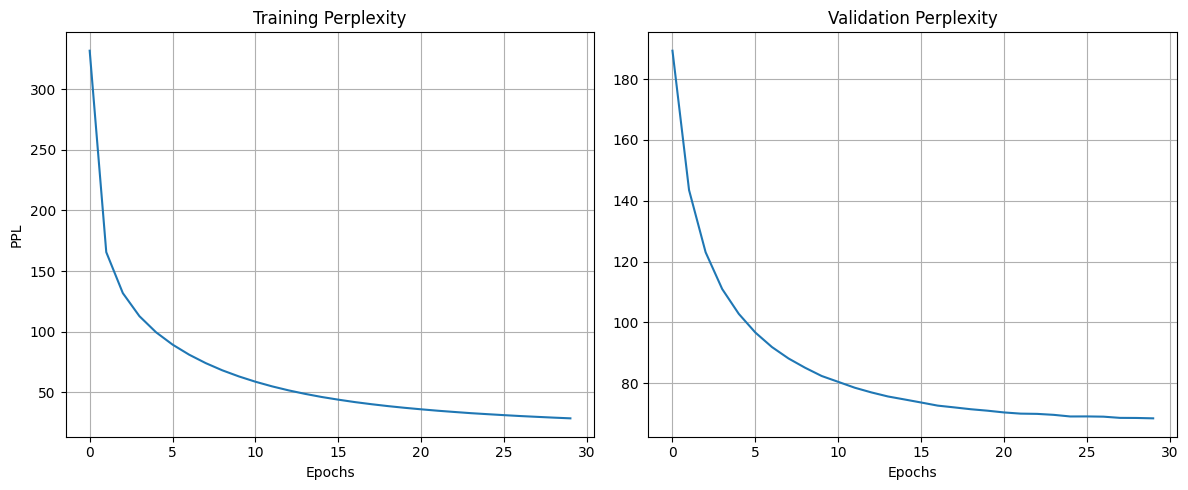

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(train_ppl)
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel('PPL')
axes[0].set_title(f"Training Perplexity")
axes[0].grid(True)

axes[1].plot(val_ppl)
axes[1].set_xlabel("Epochs")
axes[1].set_title("Validation Perplexity")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
print(f'Perplexidade mínima: {min(val_ppl):.2f} - atingida na época {val_ppl.index(min(val_ppl))+1}')

Perplexidade mínima: 68.38 - atingida na época 30


#### Testando o modelo com geração de texto

In [ ]:
def text_generation(prompt:str, n_out_text:int=20, _model=model, _vocab=vocab):
  _model.eval()

  #
  # prompt = prompt.strip().split()

  # Tokenização + adição SOS e EOS
  tokens = [0] + encoder(prompt) + [1]
  print(f'{10*"-"}\nTOKENS : {tokens} -> {decoder(tokens)}\n{10*"-"}\n')

  # manter o tamanho do contexto treinado
  context = tokens[-CONTEXT_SIZE:]
  if len(context) < CONTEXT_SIZE:
    # add PAD caso o contexto tenha contexto menor do que o esperado
    context = context + [3] * (CONTEXT_SIZE - len(context))

  print(f'{10*"-"}\nCONTEXTO : {context} -> {decoder(context)}\n{10*"-"}\n')

  generated = context.copy()

  print(20*'=')
  for m in range(n_out_text):
    # Converte para tensor
    context_tensor = torch.tensor([context]).to(device)
    print(f'ContextTensor: {context_tensor} - {context_tensor.shape}')
    with torch.no_grad():
      logits = _model(context_tensor)
      logits = logits[:, -1, :]
    # seleciona a palavra mais provável
    # token = torch.argmax(logits.squeeze(), dim=-1).item()

    # verifico quais são os 5 tokens mais prováveis
    probs = torch.softmax(logits, dim=-1)
    k_probs, k_id = torch.topk(probs, k=5)
    k_probs = k_probs.squeeze().tolist()
    k_id = k_id.squeeze().tolist()
    print('Top 5 tokens:')
    for i in range(len(k_probs)):
      print(f'\tToken: {k_id[i]} - Prob: {k_probs[i]:.4f} - {decoder([k_id[i]])}')

    # filtragem de EOS
    # Só permito que seja gerado EOS como último elemento da minha sentença
    if m == n_out_text - 1:
      token = k_id[0]
    else:
      token = [t for t in k_id if t != 1][0]

    # add token com maior probabilidade
    generated.append(token)
    context = generated[-CONTEXT_SIZE:]
    print(20*'=')

  # remover todos os tokens especiais para gerar a saída
  generated = [t for t in generated if t not in [0, 1, 2, 3]]

  return decoder(generated)

In [ ]:
full_text = text_generation('Olá meu amigo')

----------
TOKENS : [0, 17867, 63, 150, 1] -> <SOS> Olá meu amigo <EOS>
----------

----------
CONTEXTO : [0, 17867, 63, 150, 1, 3, 3, 3, 3, 3, 3, 3] -> <SOS> Olá meu amigo <EOS> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD>
----------

ContextTensor: tensor([[    0, 17867,    63,   150,     1,     3,     3,     3,     3,     3,
             3,     3]], device='cuda:0') - torch.Size([1, 12])
Top 5 tokens:
	Token: 4 - Prob: 0.4345 - ,
	Token: 5 - Prob: 0.2284 - .
	Token: 43 - Prob: 0.1299 - :
	Token: 9 - Prob: 0.0750 - e
	Token: 26 - Prob: 0.0176 - ao
ContextTensor: tensor([[17867,    63,   150,     1,     3,     3,     3,     3,     3,     3,
             3,     4]], device='cuda:0') - torch.Size([1, 12])
Top 5 tokens:
	Token: 1 - Prob: 0.7177 - <EOS>
	Token: 9 - Prob: 0.0729 - e
	Token: 7 - Prob: 0.0334 - que
	Token: 6 - Prob: 0.0206 - a
	Token: 12 - Prob: 0.0098 - não
ContextTensor: tensor([[ 63, 150,   1,   3,   3,   3,   3,   3,   3,   3,   4,   9]],
       device='cuda:0') - torch.Siz

In [ ]:
full_text

'Olá meu amigo , e que a frase era a mesma , e a única . Uma vez que o fizessem ,'

In [ ]:
full_text_2 = text_generation('Dom Casmurro')

----------
TOKENS : [0, 5341, 9292, 1] -> <SOS> Dom Casmurro <EOS>
----------

----------
CONTEXTO : [0, 5341, 9292, 1, 3, 3, 3, 3, 3, 3, 3, 3] -> <SOS> Dom Casmurro <EOS> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD>
----------

ContextTensor: tensor([[   0, 5341, 9292,    1,    3,    3,    3,    3,    3,    3,    3,    3]],
       device='cuda:0') - torch.Size([1, 12])
Top 5 tokens:
	Token: 5 - Prob: 0.3322 - .
	Token: 43 - Prob: 0.2581 - :
	Token: 4 - Prob: 0.2559 - ,
	Token: 11 - Prob: 0.0400 - ;
	Token: 9 - Prob: 0.0345 - e
ContextTensor: tensor([[5341, 9292,    1,    3,    3,    3,    3,    3,    3,    3,    3,    5]],
       device='cuda:0') - torch.Size([1, 12])
Top 5 tokens:
	Token: 1 - Prob: 0.5293 - <EOS>
	Token: 52 - Prob: 0.1304 - E
	Token: 34 - Prob: 0.0484 - A
	Token: 463 - Prob: 0.0458 - Este
	Token: 32 - Prob: 0.0365 - Não
ContextTensor: tensor([[9292,    1,    3,    3,    3,    3,    3,    3,    3,    3,    5,   52]],
       device='cuda:0') - torch.Size([1, 12])
To

In [ ]:
full_text_2

'Dom Casmurro . E não era a que se lhe dava crédito , nem o próprio Mefistófeles nolo explicaria de modo'